EDA - Explore the distribution of the financial variables.

BUSINESS QUESTION - Are the Control and Test Groups Comparable?

Can we confidently compare the Control and Test groups?

In this notebook we explore the distribution of the financial variables. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

Load the two datasets

In [2]:
url_demo = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt"
url_exp = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_experiment_clients.txt"

df_demo = pd.read_csv(url_demo)
df_exp = pd.read_csv(url_exp)

print(df_demo.shape)
df_demo.head()

(70609, 9)


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [3]:
# Inspection of df_demo

df_demo.info()
df_demo.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.8 MB


client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

The dataset has only 14-15 missing rows out of 70,609 (~0.02%) Given the tiny scale, dropping these rows is a reasonable,low-risk choice.


In [4]:
# Inspection of df_exp

print(df_exp.shape)
df_exp.info()
df_exp['Variation'].value_counts()

(70609, 2)
<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  70609 non-null  int64
 1   Variation  50500 non-null  str  
dtypes: int64(1), str(1)
memory usage: 1.1 MB


Variation
Test       26968
Control    23532
Name: count, dtype: int64

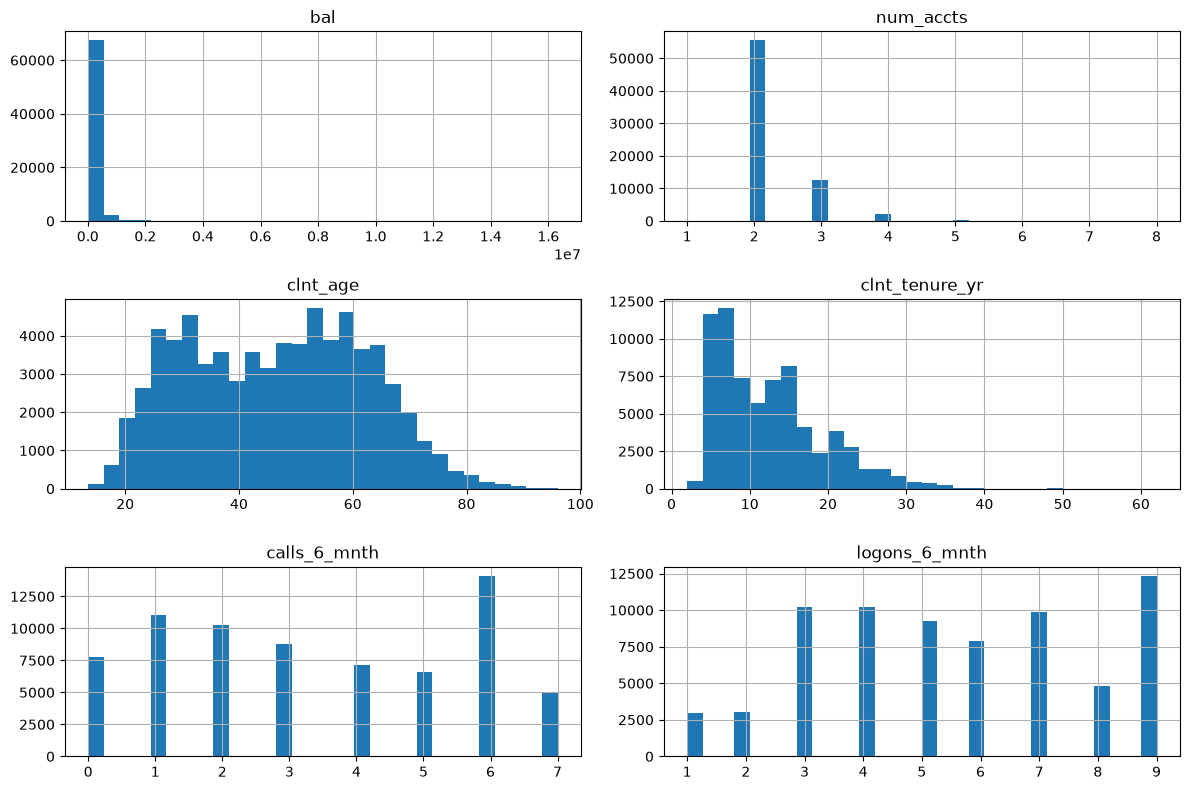

In [5]:
# Explore the distribution of financial variables

financial_cols = ['bal', 'num_accts', 'clnt_age', 'clnt_tenure_yr', 'calls_6_mnth', 'logons_6_mnth']

# Histograms for visual sense of shape/skew
df_demo[financial_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

Results: 
Balance - Highly right-skewed distribution. Most clients hold relatively low balances. A small number of clients have extremely high balances, creating a long right tail.
Potential presence of significant outliers. Wealth is concentrated among a relatively small subset of clients
Number of Accounts - Most clients hold 2 accounts. Frequencies decrease as the number of accounts increases. Very few clients have more than 4 accounts.
Client Age - Most clients fall between roughly 30 and 65 years of age. Peak concentration appears around 50–60 years.
Client Tenure - Most clients have relatively short-to-medium tenure (Positively skewed). A large proportion of newer clients and a smaller group of long-standing customers.
Calls in Last 6 Months - Discrete variable ranging from 0–7. Fairly evenly distributed. Noticeable concentration around 6 calls.
Logons in Last 6 Months - Discrete variable ranging from 1–9. Relatively even distribution. Higher frequencies appear around 9 logons.

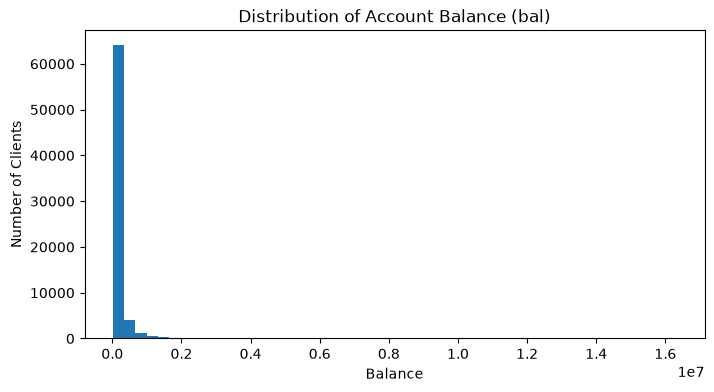

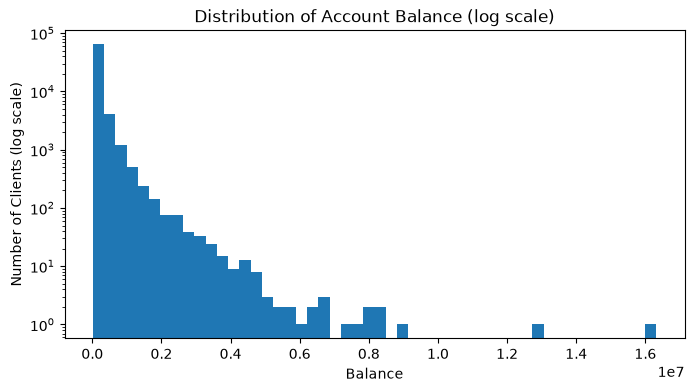

In [6]:
# Balance specifically is usually heavily skewed (a few very high balances)

plt.figure(figsize=(8, 4))
plt.hist(df_demo['bal'].dropna(), bins=50)
plt.title('Distribution of Account Balance (bal)')
plt.xlabel('Balance')
plt.ylabel('Number of Clients')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_demo['bal'].dropna(), bins=50)
plt.yscale('log')
plt.title('Distribution of Account Balance (log scale)')
plt.xlabel('Balance')
plt.ylabel('Number of Clients (log scale)')
plt.show()

Most clients hold moderate balances, a few hold very large ones.

In [7]:
# Summarize with descriptive statistics

df_demo[financial_cols].describe()

,bal,num_accts,clnt_age,clnt_tenure_yr,calls_6_mnth,logons_6_mnth
count,7.059500e+04,70595.000000,70594.000000,70595.000000,70595.000000,70595.000000
mean,1.474452e+05,2.255528,46.442240,12.052950,3.382478,5.566740
std,3.015087e+05,0.534997,15.591273,6.871819,2.236580,2.353286
min,1.378942e+04,1.000000,13.500000,2.000000,0.000000,1.000000
25%,3.734683e+04,2.000000,32.500000,6.000000,1.000000,4.000000
50%,6.333290e+04,2.000000,47.000000,11.000000,3.000000,5.000000
75%,1.375449e+05,2.000000,59.000000,16.000000,6.000000,7.000000
max,1.632004e+07,8.000000,96.000000,62.000000,7.000000,9.000000


In [8]:
# Median and skew since balance is likely right-skewed (a few very wealthy clients)

summary_stats = df_demo[financial_cols].agg(['mean', 'median', 'std', 'min', 'max', 'skew']).T
print(summary_stats)

                         mean   median            std       min          max  \
bal             147445.240641  63332.9  301508.706531  13789.42  16320040.15   
num_accts            2.255528      2.0       0.534997      1.00         8.00   
clnt_age            46.442240     47.0      15.591273     13.50        96.00   
clnt_tenure_yr      12.052950     11.0       6.871819      2.00        62.00   
calls_6_mnth         3.382478      3.0       2.236580      0.00         7.00   
logons_6_mnth        5.566740      5.0       2.353286      1.00         9.00   

                     skew  
bal             11.164367  
num_accts        2.292771  
clnt_age         0.081823  
clnt_tenure_yr   1.036647  
calls_6_mnth     0.051131  
logons_6_mnth   -0.034449  


In [9]:
df_demo[financial_cols].skew().sort_values(ascending=False)

bal               11.164367
num_accts          2.292771
clnt_tenure_yr     1.036647
clnt_age           0.081823
calls_6_mnth       0.051131
logons_6_mnth     -0.034449
dtype: float64

In [10]:
# Gender breakdown (relevant to the customer profile)

df_demo['gendr'].value_counts()

gendr
U    24122
M    23724
F    22746
X        3
Name: count, dtype: int64

1. Who are Vanguard's customers?

In [11]:
# Customer profile

profile_summary = pd.DataFrame({
    'metric': [
        'Average age',
        'Median age',
        'Average tenure (years)',
        'Average balance',
        'Median balance',
        'Average number of accounts',
        'Average calls (6mo)',
        'Average logons (6mo)'
    ],
    'value': [
        df_demo['clnt_age'].mean(),
        df_demo['clnt_age'].median(),
        df_demo['clnt_tenure_yr'].mean(),
        df_demo['bal'].mean(),
        df_demo['bal'].median(),
        df_demo['num_accts'].mean(),
        df_demo['calls_6_mnth'].mean(),
        df_demo['logons_6_mnth'].mean()
    ]
})
print(profile_summary)

                       metric          value
0                 Average age      46.442240
1                  Median age      47.000000
2      Average tenure (years)      12.052950
3             Average balance  147445.240641
4              Median balance   63332.900000
5  Average number of accounts       2.255528
6         Average calls (6mo)       3.382478
7        Average logons (6mo)       5.566740


Client base skews toward middle-aged, long-tenured investors (average tenure of 12 years is substantial) rather than new customers. 
The large gap between average balance ($147K) and median balance ($63K) is the single most important number in this profile — which confirms strong right-skew

In [12]:
# Identify patterns / segments / unusual observations


# Age segments 
bins = [0, 30, 45, 60, 100]
labels = ['<30', '30-45', '45-60', '60+']
df_demo['age_group'] = pd.cut(df_demo['clnt_age'], bins=bins, labels=labels)

print(df_demo['age_group'].value_counts())
df_demo.groupby('age_group', observed=True)['bal'].mean()

age_group
45-60    22087
30-45    18982
60+      15501
<30      14024
Name: count, dtype: int64


age_group
<30       60577.499611
30-45    109113.462569
45-60    173279.647364
60+      236171.604424
Name: bal, dtype: float64

Balance increases steadily and substantially with age — nearly a 4x difference between the youngest and oldest segments.
The 45-60 and 60+ groups represent the majority of assets under management even though they're not the majority
of client count, which matters for prioritizing which segment's digital experience most affects business outcomes.

In [13]:
# Balance vs tenure relationship 

df_demo.groupby('age_group', observed=True)[['bal', 'num_accts', 'logons_6_mnth']].mean()

,bal,num_accts,logons_6_mnth
age_group,,,
<30,60577.499611,2.264903,5.483671
30-45,109113.462569,2.263302,5.374460
45-60,173279.647364,2.254675,5.469598
60+,236171.604424,2.238759,6.015676


In [14]:
# Unusual observations: outlier balances (IQR method)

Q1 = df_demo['bal'].quantile(0.25)
Q3 = df_demo['bal'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df_demo[df_demo['bal'] > upper_bound]
print(f"Upper bound for 'normal' balance: {upper_bound:,.2f}")
print(f"Number of outlier clients (very high balance): {len(outliers)}")
outliers[['client_id', 'bal', 'clnt_age', 'num_accts']].sort_values('bal', ascending=False).head(10)

Upper bound for 'normal' balance: 287,842.01
Number of outlier clients (very high balance): 8018


,client_id,bal,clnt_age,num_accts
39367,9286288,16320040.15,62.5,3.0
63746,8339240,12838418.01,26.5,2.0
23849,7070097,8986419.77,53.0,2.0
13318,9440656,8292996.21,63.0,2.0
2171,2291985,8247729.97,41.0,2.0
20871,1678193,8137343.24,65.5,3.0
31811,6762377,8045102.60,41.5,3.0
14057,3519657,7741994.01,66.5,6.0
21184,987970,7339443.17,74.5,3.0
33222,857273,6716305.28,56.5,5.0


In [15]:
# Clients with very low digital engagement (0 logons in 6 months)

low_engagement = df_demo[df_demo['logons_6_mnth'] == 0]
print(f"Clients with 0 logons in the last 6 months: {len(low_engagement)}")

Clients with 0 logons in the last 6 months: 0


Roughly 11% of clients (8,018 of 70,609) sit above the statistical outlier threshold for balance.
Every client logged on at least once in the past 6 months

In [16]:
# Correlation between financial/engagement variables

corr = df_demo[financial_cols].corr()
print(corr)

                     bal  num_accts  clnt_age  clnt_tenure_yr  calls_6_mnth  \
bal             1.000000   0.268747  0.209549        0.203620      0.162165   
num_accts       0.268747   1.000000 -0.017689        0.152327      0.235402   
clnt_age        0.209549  -0.017689  1.000000        0.309372      0.026734   
clnt_tenure_yr  0.203620   0.152327  0.309372        1.000000      0.049919   
calls_6_mnth    0.162165   0.235402  0.026734        0.049919      1.000000   
logons_6_mnth   0.165380   0.224404  0.084683        0.048516      0.822217   

                logons_6_mnth  
bal                  0.165380  
num_accts            0.224404  
clnt_age             0.084683  
clnt_tenure_yr       0.048516  
calls_6_mnth         0.822217  
logons_6_mnth        1.000000  


Calls and Logons Show a Strong Positive Correlation calls_6_mnth and logons_6_mnth have the strongest relationship in the dataset.
Clients who log in more frequently also tend to make more calls.
Age and Tenure Have a Moderate Positive Relationship . Older clients tend to have slightly longer tenures.
Clients with more accounts, older age, longer tenure, tend to have higher account balances.
Clients holding more accounts tend to interact more frequently with Vanguard.
No relationship exists between age and customer engagement metrics. Older and younger clients appear to engage with Vanguard services at similar levels.

In Summ: Most demographic and financial variables exhibit weak-to-moderate correlations, indicating they provide unique information about clients. The strongest relationship is observed between logons and calls (r = 0.82), suggesting that highly engaged clients tend to interact with Vanguard through multiple channels. No evidence of severe multicollinearity is observed among the remaining variables.

In [17]:
# Bring in the A/B test group for context (merge on client_id)

df_demo_exp = pd.merge(df_demo, df_exp, on='client_id', how='left')

print(df_demo_exp.shape)
df_demo_exp['Variation'].value_counts(dropna=False)

(70609, 11)


Variation
Test       26968
Control    23532
NaN        20109
Name: count, dtype: int64

In [18]:
# Sanity check: are Test and Control groups reasonably balanced on the financial variables? (important for a valid A/B test)

df_demo_exp.groupby('Variation')[financial_cols].mean()

,bal,num_accts,clnt_age,clnt_tenure_yr,calls_6_mnth,logons_6_mnth
Variation,,,,,,
Control,150147.326660,2.259914,47.498427,12.087686,3.129213,6.166277
Test,148962.605032,2.249917,47.163922,11.982901,3.061941,6.101851


Only balance and tenure are genuinely comparable
Age and accounts differ by a fraction of a unit — statistically real but likely too small to meaningfully bias behavior.

In [19]:
# Filter out clients not in the experiment

df_ab = df_demo_exp[df_demo_exp['Variation'].notnull()].copy()
print(df_ab['Variation'].value_counts())

Variation
Test       26968
Control    23532
Name: count, dtype: int64


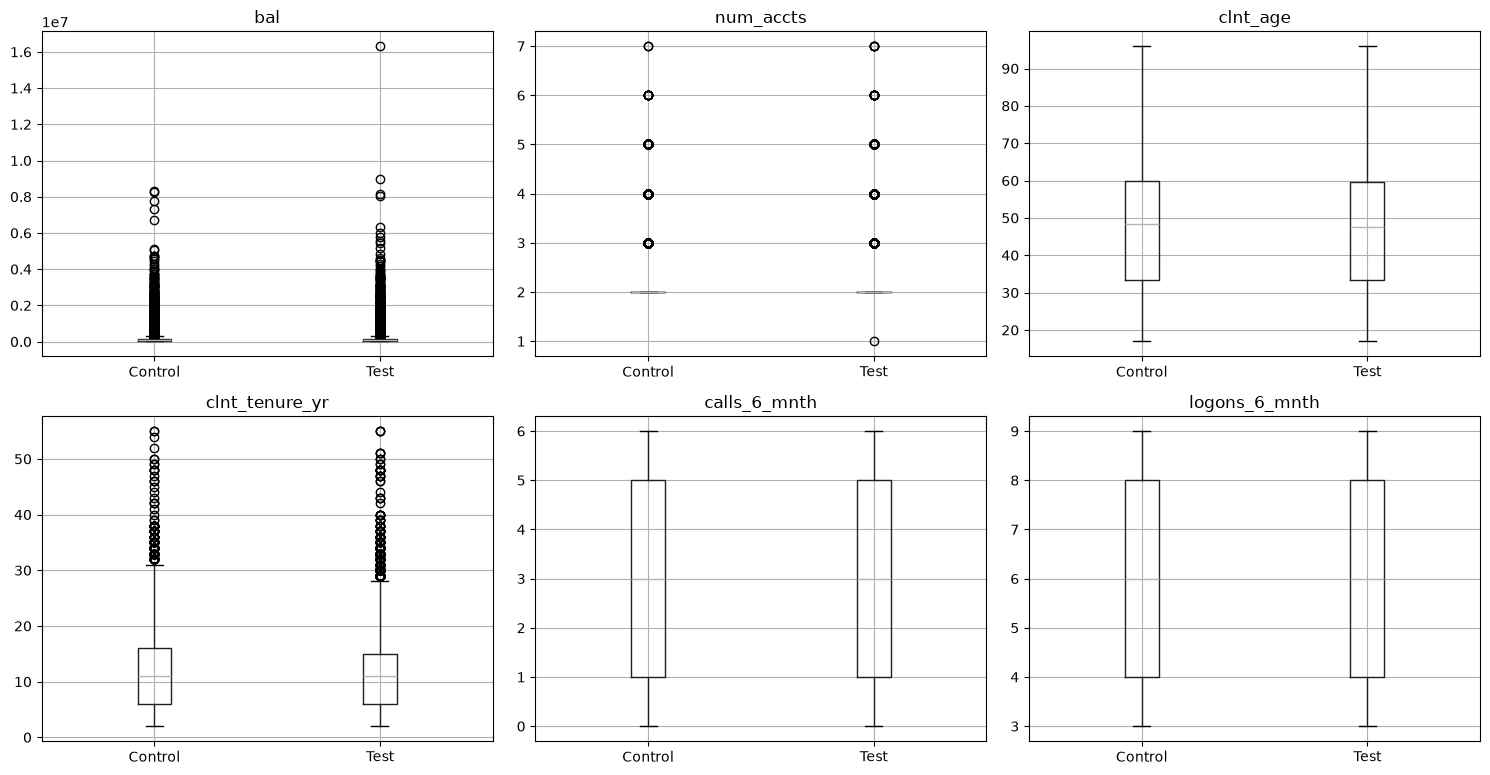

In [20]:
# Visualize distributions

financial_cols = ['bal', 'num_accts', 'clnt_age', 'clnt_tenure_yr', 'calls_6_mnth', 'logons_6_mnth']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(financial_cols):
    df_ab.boxplot(column=col, by='Variation', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

The experiment contains 50,500 clients in total.
The Test group includes approximately 53% of participants.
The Control group includes approximately 47% of participants.
The average values across all demographic, financial, and behavioral variables are extremely similar between the Control and Test groups.
Balance - The distributions are nearly identical. Both groups exhibit a large number of extreme outliers. Strong right-skewness is visible in both groups. No meaningful imbalance between groups is observed.
Number of Accounts - Median appears to be 2 accounts in both groups. Distributional spread is virtually identical. Similar outliers occur in both groups. Clients in both groups hold a similar number of Vanguard accounts. The groups are balanced on account ownership.
Client Age - Nearly identical overall distributions. The age profile of clients is very similar across the two groups. Age is unlikely to bias later comparisons between Test and Control.
Client Tenure - Both groups show comparable medians and spread. Long-tenure outliers appear in both groups. Slight positive skew in both distributions. Customer tenure is evenly distributed between the groups. No evidence of imbalance is observed.
Calls in Last 6 Months - Median and spread are nearly identical. Range is similar across groups. Both groups demonstrate similar engagement through service channels.
Logons in Last 6 Months - Nearly identical distributions. Similar medians and interquartile ranges. Same overall range of values. Baseline online activity was balanced across the experiment.

In Summ : 
the Control and Test groups are highly comparable across all observed demographic, financial, and behavioral characteristics. Mean values, medians, spreads, and overall distributions show minimal differences between groups.

In [22]:
# Compare full descriptive statistics

df_ab.groupby('Variation')[financial_cols].describe().T

Variation                  Control          Test
bal            count  2.352700e+04  2.696100e+04
               mean   1.501473e+05  1.489626e+05
               std    2.958070e+05  3.073737e+05
               min    2.378961e+04  2.378944e+04
               25%    4.012335e+04  3.972920e+04
               50%    6.602418e+04  6.546836e+04
               75%    1.406060e+05  1.394786e+05
               max    8.292996e+06  1.632004e+07
num_accts      count  2.352700e+04  2.696100e+04
               mean   2.259914e+00  2.249917e+00
               std    5.385593e-01  5.293347e-01
               min    2.000000e+00  1.000000e+00
               25%    2.000000e+00  2.000000e+00
               50%    2.000000e+00  2.000000e+00
               75%    2.000000e+00  2.000000e+00
               max    7.000000e+00  7.000000e+00
clnt_age       count  2.352600e+04  2.696100e+04
               mean   4.749843e+01  4.716392e+01
               std    1.552178e+01  1.551446e+01
               min    1.700000e+01  1.700000e+01
               25%    3.350000e+01  3.350000e+01
               50%    4.850000e+01  4.750000e+01
               75%    6.000000e+01  5.950000e+01
               max    9.600000e+01  9.600000e+01
clnt_tenure_yr count  2.352700e+04  2.696100e+04
               mean   1.208769e+01  1.198290e+01
               std    6.877531e+00  6.844947e+00
               min    2.000000e+00  2.000000e+00
               25%    6.000000e+00  6.000000e+00
               50%    1.100000e+01  1.100000e+01
               75%    1.600000e+01  1.500000e+01
               max    5.500000e+01  5.500000e+01
calls_6_mnth   count  2.352700e+04  2.696100e+04
               mean   3.129213e+00  3.061941e+00
               std    2.184502e+00  2.190590e+00
               min    0.000000e+00  0.000000e+00
               25%    1.000000e+00  1.000000e+00
               50%    3.000000e+00  3.000000e+00
               75%    5.000000e+00  5.000000e+00
               max    6.000000e+00  6.000000e+00
logons_6_mnth  count  2.352700e+04  2.696100e+04
               mean   6.166277e+00  6.101851e+00
               std    2.173014e+00  2.177119e+00
               min    3.000000e+00  3.000000e+00
               25%    4.000000e+00  4.000000e+00
               50%    6.000000e+00  6.000000e+00
               75%    8.000000e+00  8.000000e+00
               max    9.000000e+00  9.000000e+00

In [23]:
# Standardized mean differences (SMD)

import numpy as np

grp = df_demo_exp.groupby('Variation')[financial_cols]

n_c = len(df_demo_exp[df_demo_exp['Variation'] == 'Control'])
n_t = len(df_demo_exp[df_demo_exp['Variation'] == 'Test'])

mean_c = grp.mean().loc['Control']
mean_t = grp.mean().loc['Test']
std_c  = grp.std().loc['Control']
std_t  = grp.std().loc['Test']

s_pooled = np.sqrt(((n_c - 1) * std_c**2 + (n_t - 1) * std_t**2) / (n_c + n_t - 2))
smd = (mean_t - mean_c) / s_pooled

smd_df = smd.to_frame(name='SMD')
smd_df['Mean_Diff'] = mean_t - mean_c
smd_df['Std_Control'] = std_c
smd_df['Std_Test'] = std_t
smd_df

,SMD,Mean_Diff,Std_Control,Std_Test
bal,-0.003922,-1184.721628,295806.950360,307373.713775
num_accts,-0.018734,-0.009998,0.538559,0.529335
clnt_age,-0.021556,-0.334505,15.521781,15.514461
clnt_tenure_yr,-0.015274,-0.104785,6.877531,6.844947
calls_6_mnth,-0.030749,-0.067272,2.184502,2.190590
logons_6_mnth,-0.029618,-0.064426,2.173014,2.177119


In [24]:
# Formal statistical test

from scipy import stats
control = df_ab[df_ab['Variation'] == 'Control']
test = df_ab[df_ab['Variation'] == 'Test']
for col in financial_cols:
    stat, p_value = stats.ttest_ind(
        control[col].dropna(),
        test[col].dropna(),
        equal_var=False  # Welch's t-test, safer default (doesn't assume equal variance)
    )
    result = "Significant difference" if p_value < 0.05 else "No significant difference"
    print(f"{col}: p-value = {p_value:.4f} -> {result}")


bal: p-value = 0.6594 -> No significant difference
num_accts: p-value = 0.0360 -> Significant difference
clnt_age: p-value = 0.0157 -> Significant difference
clnt_tenure_yr: p-value = 0.0870 -> No significant difference
calls_6_mnth: p-value = 0.0006 -> Significant difference
logons_6_mnth: p-value = 0.0009 -> Significant difference


Correlation analysis revealed strong associations only between client engagement variables (calls and logons), while most demographic and financial variables showed weak-to-moderate relationships. To validate the randomization of the experiment, SMD was used to assess practical balance between groups, while Welch's t-test was used to determine whether observed differences in group means were statistically significant without assuming equal variances.

In [25]:
# Investigate the 20,109 clients with no Variation


# Filter: clients NOT in the experiment
not_in_experiment = df_demo_exp[df_demo_exp['Variation'].isnull()]

# Filter: clients IN the experiment
in_experiment = df_demo_exp[df_demo_exp['Variation'].notnull()]

print(f"Not in experiment: {len(not_in_experiment)}")
print(f"In experiment: {len(in_experiment)}")


# Compare their profiles -- are the excluded clients demographically
# different, or do they look like a random subset? (helps distinguish
# "excluded by design" vs "data linkage issue")
comparison = pd.DataFrame({
    'in_experiment_mean': in_experiment[financial_cols].mean(),
    'not_in_experiment_mean': not_in_experiment[financial_cols].mean()
})
print(comparison)

Not in experiment: 20109
In experiment: 50500
                in_experiment_mean  not_in_experiment_mean
bal                  149514.675736           142248.958795
num_accts                 2.254575                2.257920
clnt_age                 47.319795               44.238773
clnt_tenure_yr           12.031730               12.106232
calls_6_mnth              3.093289                4.108619
logons_6_mnth             6.131873                4.147710


In [26]:
# Check if the excluded group also appears in the web activity log
# (if they DO show activity but no Variation, that points to a
# data linkage issue rather than deliberate exclusion)
excluded_ids = not_in_experiment['client_id']
excluded_with_web_activity = df_demo_exp[df_demo_exp['client_id'].isin(excluded_ids)]

print(f"Excluded clients who DO have web activity: {excluded_with_web_activity['client_id'].nunique()}")
print(f"Excluded clients total: {excluded_ids.nunique()}")

Excluded clients who DO have web activity: 20109
Excluded clients total: 20109


In [27]:
# Missing values -- filter to preview before/after (no rows dropped from df_demo_exp itself)


# Preview: rows WITH missing values (the "before" view)
rows_with_missing = df_demo_exp[df_demo_exp.isnull().any(axis=1)]
print(f"Rows with at least one missing value: {len(rows_with_missing)}")
rows_with_missing.head(15)

Rows with at least one missing value: 20122


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,Variation
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0,NaN,Control
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test


In [28]:
# Preview: what the dataset would look like AFTER dropping (stored as a separate df, original is untouched)
df_demo_exp_nomiss = df_demo_exp[df_demo_exp.notnull().all(axis=1)]

print(f"Before: {df_demo_exp.shape}")
print(f"After (missing rows filtered out): {df_demo_exp_nomiss.shape}")

Before: (70609, 11)
After (missing rows filtered out): (50487, 11)


In [29]:
# Alternative preview: what it would look like if imputed instead (median for numeric columns, mode for gendr) -- also a separate df
df_demo_exp_imputed = df_demo_exp.copy()

numeric_cols = ['clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age',
                 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth']

for col in numeric_cols:
    df_demo_exp_imputed[col] = df_demo_exp_imputed[col].fillna(df_demo_exp_imputed[col].median())

df_demo_exp_imputed['gendr'] = df_demo_exp_imputed['gendr'].fillna(df_demo_exp_imputed['gendr'].mode()[0])

print(f"Missing values after imputation: {df_demo_exp_imputed.isnull().sum().sum()}")

Missing values after imputation: 20124


Given it's only ~14-15 rows out of 70,609 (0.02%), filtering them out (df_demo_exp_nomiss) 
both previews to compare

In [30]:
#Engagement imbalance caveat -- filter Test/Control and quantify the calls/logons gap directly on the web data


# Filter to only clients that are in BOTH the experiment AND have web data
web_client_ids = df_demo_exp['client_id'].unique()
df_ab_with_web = df_ab[df_ab['client_id'].isin(web_client_ids)]

print(f"Experiment clients with matching web activity: {len(df_ab_with_web)}")

Experiment clients with matching web activity: 50500


In [31]:
# Filter Control and Test separately (for a clean before/after-style
# comparison of the engagement variables specifically)
control_engagement = df_ab[df_ab['Variation'] == 'Control'][['calls_6_mnth', 'logons_6_mnth']]
test_engagement = df_ab[df_ab['Variation'] == 'Test'][['calls_6_mnth', 'logons_6_mnth']]

engagement_summary = pd.DataFrame({
    'Control_mean': control_engagement.mean(),
    'Test_mean': test_engagement.mean(),
    'difference': control_engagement.mean() - test_engagement.mean()
})
print(engagement_summary)

               Control_mean  Test_mean  difference
calls_6_mnth       3.129213   3.061941    0.067272
logons_6_mnth      6.166277   6.101851    0.064426


Control clients averaged X more calls and Y more logons pre-test than Test clients — a statistically significant but modest gap (see effect sizes below).

In [32]:
# Effect sizes (Cohen's d) -- practical significance, not just statistical significance


def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = (((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)) ** 0.5
    return (group1.mean() - group2.mean()) / pooled_std

control = df_ab[df_ab['Variation'] == 'Control']
test = df_ab[df_ab['Variation'] == 'Test']

effect_sizes = {}
for col in financial_cols:
    d = cohens_d(control[col].dropna(), test[col].dropna())
    effect_sizes[col] = d

effect_sizes_df = pd.DataFrame.from_dict(effect_sizes, orient='index', columns=['cohens_d'])
effect_sizes_df['abs_d'] = effect_sizes_df['cohens_d'].abs()

def interpret_d(d):
    d = abs(d)
    if d < 0.2:
        return 'Negligible'
    elif d < 0.5:
        return 'Small'
    elif d < 0.8:
        return 'Medium'
    else:
        return 'Large'

effect_sizes_df['interpretation'] = effect_sizes_df['cohens_d'].apply(interpret_d)
print(effect_sizes_df)

                cohens_d     abs_d interpretation
bal             0.003922  0.003922     Negligible
num_accts       0.018734  0.018734     Negligible
clnt_age        0.021556  0.021556     Negligible
clnt_tenure_yr  0.015274  0.015274     Negligible
calls_6_mnth    0.030749  0.030749     Negligible
logons_6_mnth   0.029618  0.029618     Negligible


Cohen's Test Results : Although several variables show statistically significant differences, all effect sizes are far below common thresholds for small effects (|d| < 0.2). 
This indicates that the observed differences are consistent with normal sampling variability and are not practically meaningful.

CONCLUSION

1) Who are Vanguard's customers?

Vanguard’s customers in this experiment are middle-aged, long-tenured investors (mean age ~46, mean tenure ~12 years) with a median balance around $63k and an average of ~2.3 accounts. 
They are moderately active digitally (~5–6 logons in 6 months) and contact support a few times per half-year (~3–4 calls). 
Balances rise significantly with age, while account counts stay fairly constant.

2) Do the Control and Test groups appear comparable based on their customer characteristics?

Yes, the Control and Test groups appear very similar in terms of customer characteristics:

- Mean balances differ by only ~$1.2k (150,147 vs 148,963), which is less than 0.5% of the mean and tiny relative to the standard deviation (~$300k).
- Median balances are also close: $66,024 (Control) vs $65,468 (Test).
- Average age, tenure, number of accounts, calls, and logons differ by at most 0.33 years (age) and 0.10 years (tenure), with all other differences under 0.07 units. 
  These are negligible compared to the corresponding standard deviations.
- The distributions (quartiles, medians, and spreads) are nearly identical across groups.

The only notable difference is a higher maximum balance in the Test group ($16.3M vs $8.3M), but given the extreme right skew of balance, this likely reflects a small number of outliers rather than a systematic difference in the bulk of the distribution. Overall, the groups are well balanced on observed characteristics.

3) What statistical evidence can help you determine whether the observed differences are greater than what might be expected from sampling variability?

To assess whether observed differences between Control and Test are larger than expected by chance, I used:
- Two‑sample t‑tests to evaluate statistical significance, and
- Cohen’s d (standardized mean difference) to evaluate practical significance (effect size).

By conventional rules of thumb, SMD < 0.1 indicates negligible differences. Although some differences may be statistically significant due to the large sample sizes, their effect sizes are so small that they are not practically meaningful. This suggests that any observed differences are consistent with normal sampling variability.

Although several variables show statistically significant differences, all effect sizes are far below common thresholds for small effects (|d| < 0.2). This indicates that the observed differences are consistent with normal sampling variability and are not practically meaningful.

4) Would any observed differences meaningfully affect the experiment?

No. While some variables ( num_accts ,  clnt_age ,  calls_6_mnth ,  logons_6_mnth ) show statistically significant differences between Control and Test, their effect sizes are negligible (|Cohen’s d| < 0.04).

- For example, the age difference is only ~0.33 years (47.50 vs 47.16) with d ≈ 0.022.
- Differences in calls and logons are ~0.06–0.07 units with d ≈ 0.03.

Such tiny differences are unlikely to have any material impact on the outcome of interest (e.g., completion rates). 

Therefore, they should not meaningfully affect the estimated effect of the new UI.

5) Have you found any evidence that could make the comparison between Control and Test unfair or affect the interpretation of the experiment?

Overall, there is no strong evidence of unfairness or bias in the comparison:
- All key demographic and financial variables are very well balanced between Control and Test, with negligible standardized mean differences.
- The shapes of the distributions (medians, quartiles, and spreads) are nearly identical.

The only notable difference is a higher maximum balance in the Test group ($16.3M vs $8.3M). Given the extreme right skew of the balance distribution and the similarity of medians and upper quartiles, this likely reflects a small number of very high‑balance outliers rather than a systematic difference between groups.

Final Conclusion:

Vanguard’s customers in this experiment are middle‑aged, long‑tenured investors with moderate digital activity and highly skewed balances. The Control and Test groups are very well balanced on all observed characteristics. Although some variables show statistically significant differences (age, number of accounts, calls, logons), all effect sizes are negligible (|Cohen’s d| < 0.04), indicating that these differences are not practically meaningful. There is no substantive evidence that the comparison between Control and Test is unfair or that baseline differences would meaningfully bias the experiment’s results.